# A Test for how Different dropout probabilities affect unconditional sampling distribution

In [1]:
import importlib
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

import model as _model_mod; importlib.reload(_model_mod)
import data as _data_mod;   importlib.reload(_data_mod)
import flow as _flow_mod;   importlib.reload(_flow_mod)

from model import MLPVelocity, ConditionalMLPVelocity
from data import SwissrollWithLabel, sample_noise
from flow import flow_pair, sample_t, flow_matching_loss, sample_trajectory

def plot_batch(batch, **kwargs):
    arr = batch.cpu().numpy()
    plt.scatter(arr[:, 0], arr[:, 1], marker='.', **kwargs)

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

# Load pre-trained unconditional backbone

Load weights saved by `pretrain.ipynb`.  The backbone already knows the general Swiss-roll velocity field; we only need to teach it to use condition labels.

In [2]:
device = torch.device('cpu')
backbone = MLPVelocity().to(device)
backbone.load_state_dict(torch.load('pretrained_backbone.pt', map_location=device, weights_only=True))
backbone.eval()
print('Backbone loaded ✓')

Backbone loaded ✓


/opt/homebrew/anaconda3/envs/rl/lib/python3.10/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


# Build conditional model（说明）

每个 dropout 都会 **重新** `ConditionalMLPVelocity.from_pretrained(backbone, dropout_prob=…)`：主干从同一 `backbone` 拷贝，第一层扩维部分仍为零初始化，故每个实验在 fine-tune 起点上等价于无条件场。具体实例在 **Fine-tune** 格中按 `DROPOUTS` 循环创建。

In [3]:
# `ConditionalMLPVelocity` 实例在下一格按 dropout 列表逐个 `from_pretrained` 构建。


# Data

Load `SwissrollWithLabel` — a 2D Swiss roll split into 7 class segments (see `test.ipynb` for the stand-alone visualisation).

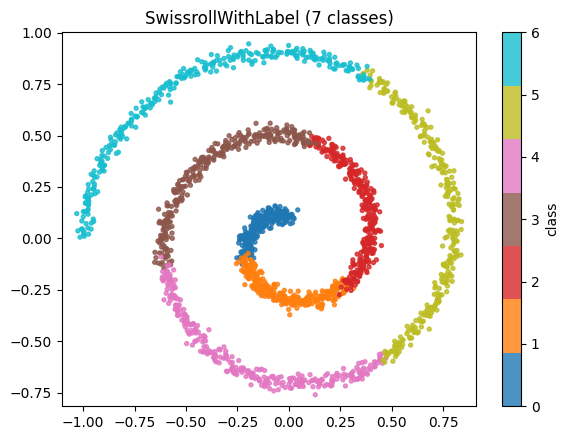

In [4]:
dataset = SwissrollWithLabel()
loader = DataLoader(dataset, batch_size=len(dataset))

pts = np.array([dataset[i][0].numpy() for i in range(len(dataset))])
labels = np.array([dataset[i][1] for i in range(len(dataset))])

num_classes_ds = SwissrollWithLabel.NUM_CLASSES
try:
    cmap_ds = plt.colormaps["tab10"].resampled(num_classes_ds)
except AttributeError:
    cmap_ds = plt.cm.get_cmap("tab10", num_classes_ds)

plt.figure(figsize=(6, 4.5))
scatter = plt.scatter(
    pts[:, 0],
    pts[:, 1],
    c=labels,
    cmap=cmap_ds,
    vmin=0,
    vmax=num_classes_ds - 1,
    s=8,
    alpha=0.8,
)
cbar = plt.colorbar(scatter, label="class", ticks=np.arange(num_classes_ds))
cbar.ax.set_yticklabels([str(i) for i in range(num_classes_ds)])
plt.axis('equal')
plt.title('SwissrollWithLabel (7 classes)')
plt.tight_layout()
plt.show()

# Fine-tune

对 `DROPOUTS = np.linspace(0, 1, 6)` 中每个 dropout 各训练一个 `ConditionalMLPVelocity`（均从同一 `backbone` 初始化）。损失曲线画在同一张图上。


In [5]:
DROPOUTS = np.linspace(0.0, 1.0, 6)  # 0 与 1 均包含，共 6 档
epochs = 8000
lr = 1e-4
log_every = 500  # 打印训练进度

torch.manual_seed(42)
all_losses: list[list[float]] = []
trained_models: list = []

for run_i, dropout_prob in enumerate(DROPOUTS):
    dp = float(dropout_prob)
    print(f"\n{'='*60}\n[{run_i + 1}/6] dropout_prob = {dp:.4f}\n{'='*60}")
    torch.manual_seed(1234)  # 六种 dropout 共用同一随机初始化，仅训练时 dropout 率不同
    cond_model = ConditionalMLPVelocity.from_pretrained(
        backbone,
        cond_dim=4,
        num_classes=SwissrollWithLabel.NUM_CLASSES,
        dropout_prob=dp,
    ).to(device)
    opt = torch.optim.Adam(cond_model.parameters(), lr=lr)
    losses_run: list[float] = []

    for epoch in range(epochs):
        cond_model.train()
        batch_losses: list[float] = []
        for x1_b, labels_b in loader:
            x1_b = x1_b.to(device)
            labels_b = labels_b.to(device)
            x0 = sample_noise(x1_b.size(0), device=device)
            t = sample_t(x1_b.size(0), device)
            x_t, target_v = flow_pair(x0, x1_b, t)
            pred_v = cond_model(x_t, t, labels_b)
            loss = flow_matching_loss(pred_v, target_v)
            opt.zero_grad()
            loss.backward()
            opt.step()
            losses_run.append(loss.item())
            batch_losses.append(loss.item())
        if epoch == 0 or (epoch + 1) % log_every == 0 or epoch + 1 == epochs:
            print(
                f"  dropout={dp:.2f}  epoch {epoch + 1:5d}/{epochs}  "
                f"last_batch_loss={batch_losses[-1]:.6f}  epoch_mean={float(np.mean(batch_losses)):.6f}"
            )

    cond_model.eval()
    trained_models.append(cond_model)
    all_losses.append(losses_run)
    print(f"  -> finished dropout={dp:.4f}, total steps={len(losses_run)}")



[1/6] dropout_prob = 0.0000
  dropout=0.00  epoch     1/8000  last_batch_loss=0.629528  epoch_mean=0.629528
  dropout=0.00  epoch   500/8000  last_batch_loss=0.576303  epoch_mean=0.576303
  dropout=0.00  epoch  1000/8000  last_batch_loss=0.518356  epoch_mean=0.518356
  dropout=0.00  epoch  1500/8000  last_batch_loss=0.413537  epoch_mean=0.413537
  dropout=0.00  epoch  2000/8000  last_batch_loss=0.341423  epoch_mean=0.341423
  dropout=0.00  epoch  2500/8000  last_batch_loss=0.277280  epoch_mean=0.277280
  dropout=0.00  epoch  3000/8000  last_batch_loss=0.266322  epoch_mean=0.266322
  dropout=0.00  epoch  3500/8000  last_batch_loss=0.264838  epoch_mean=0.264838
  dropout=0.00  epoch  4000/8000  last_batch_loss=0.280035  epoch_mean=0.280035
  dropout=0.00  epoch  4500/8000  last_batch_loss=0.261768  epoch_mean=0.261768
  dropout=0.00  epoch  5000/8000  last_batch_loss=0.280550  epoch_mean=0.280550
  dropout=0.00  epoch  5500/8000  last_batch_loss=0.269511  epoch_mean=0.269511
  dropout=0

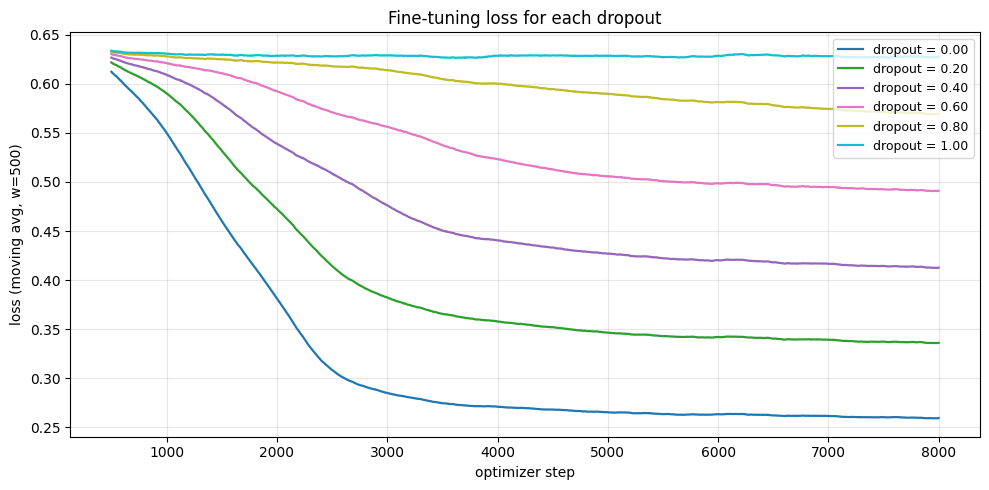

In [6]:
win = 500
try:
    cmap_lines = plt.colormaps["tab10"].resampled(len(DROPOUTS))
except AttributeError:
    cmap_lines = plt.cm.get_cmap("tab10", len(DROPOUTS))

plt.figure(figsize=(10, 5))
for i, dp in enumerate(DROPOUTS):
    raw = all_losses[i]
    sm = moving_average(raw, win)
    x_axis = np.arange(len(sm)) + (win - 1)
    plt.plot(x_axis, sm, color=cmap_lines(i / max(1, len(DROPOUTS) - 1)), lw=1.6, label=f"dropout = {dp:.2f}")
plt.xlabel("optimizer step")
plt.ylabel(f"loss (moving avg, w={win})")
plt.title("Fine-tuning loss for each dropout")
plt.legend(loc="upper right", fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Conditional sampling

对每种 **dropout**，生成 **一张图**：左侧为 **7 个 class** 的终点叠在同一张坐标系（颜色与 Data 节 `tab10` 七色一致）；右侧 **单独**为 **Unconditional**。共 6 张图。


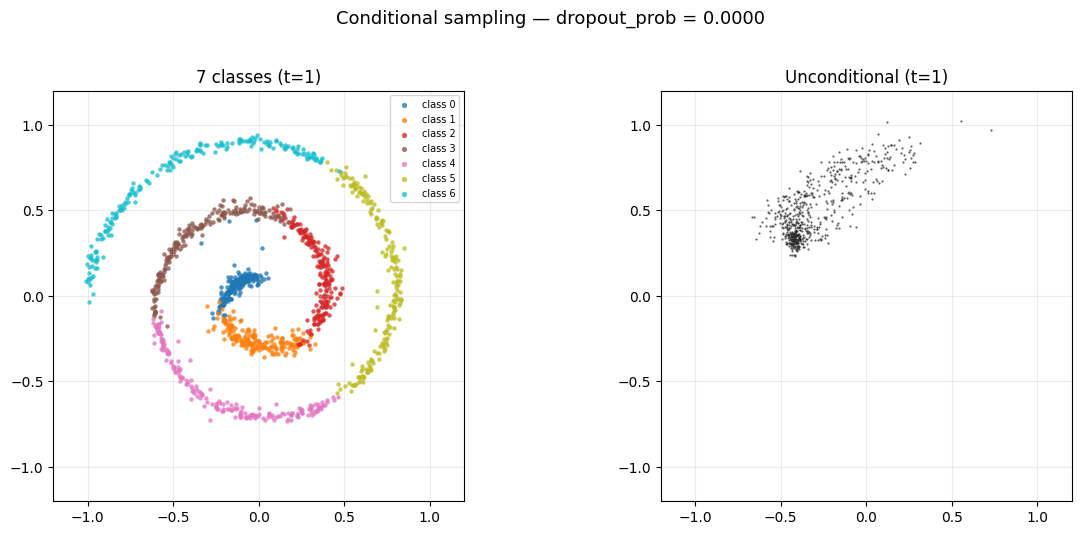

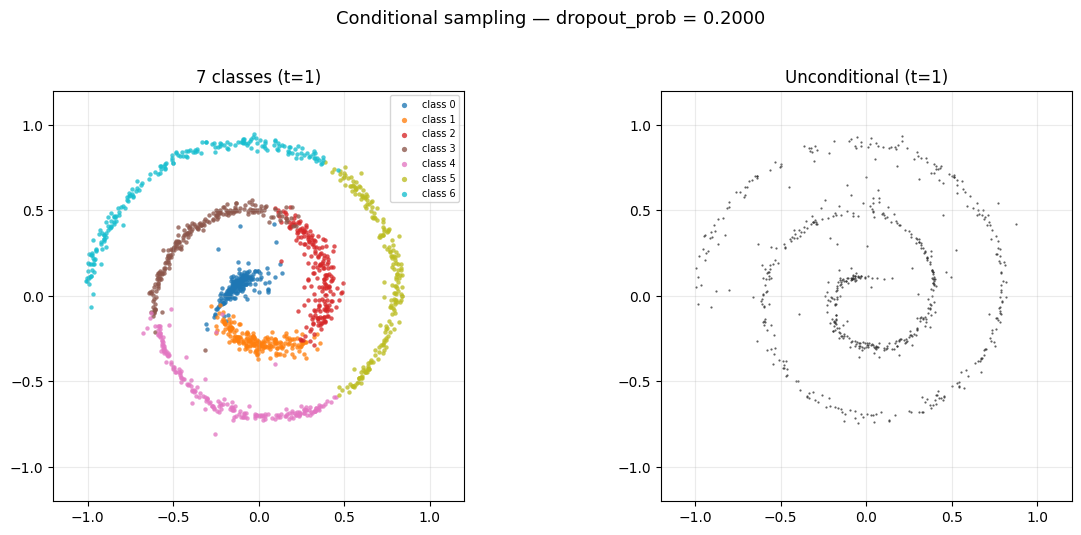

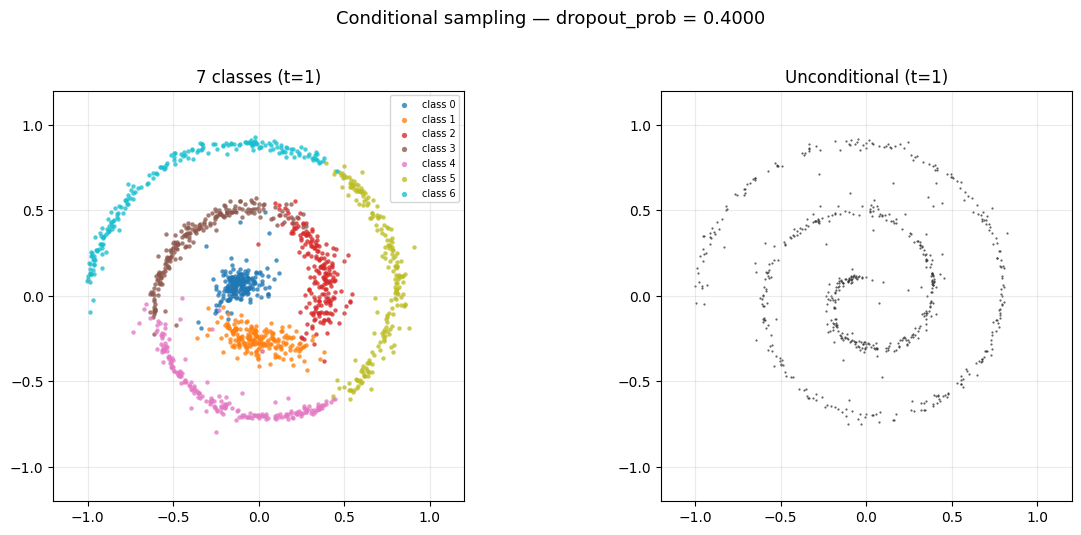

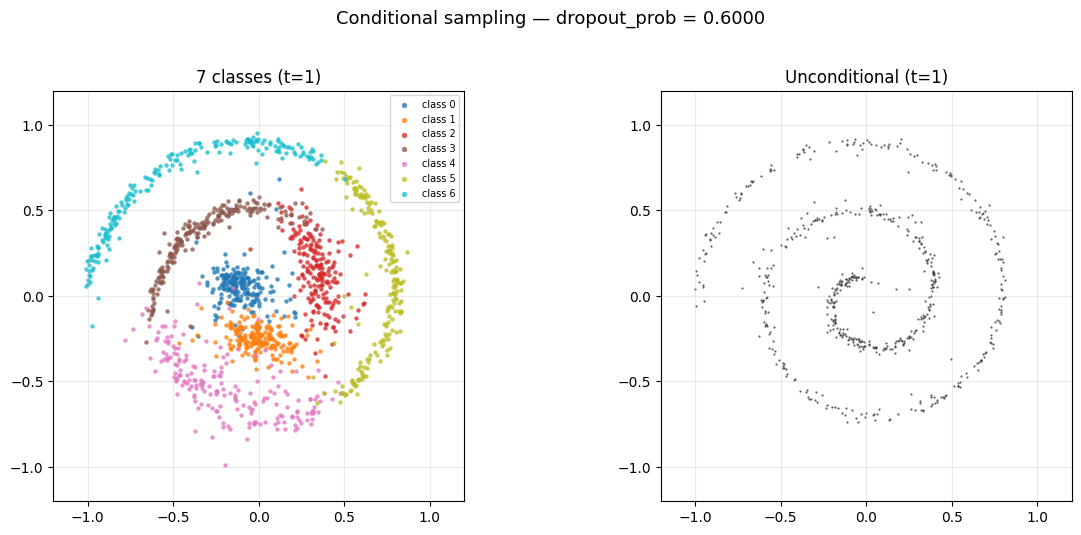

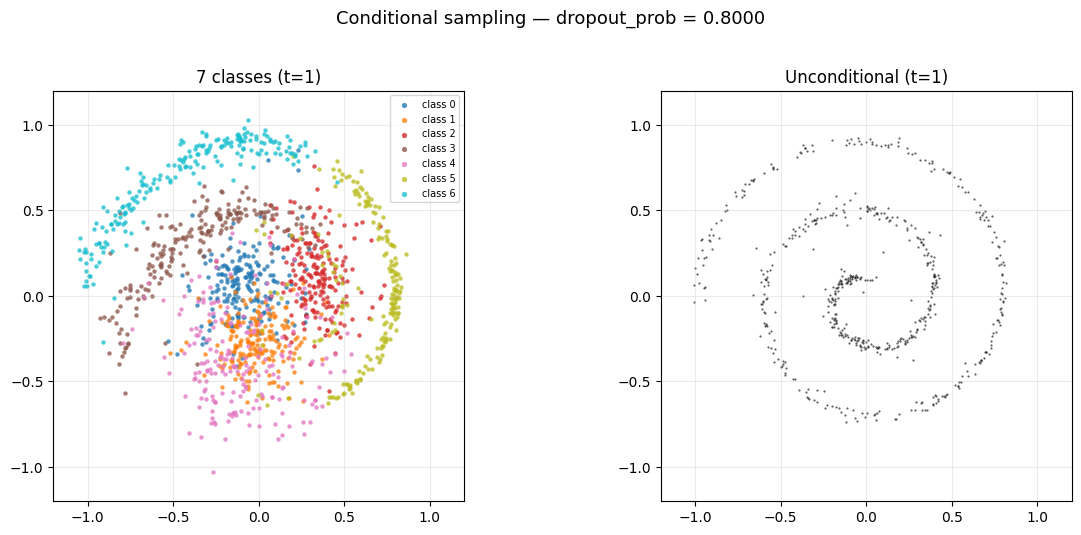

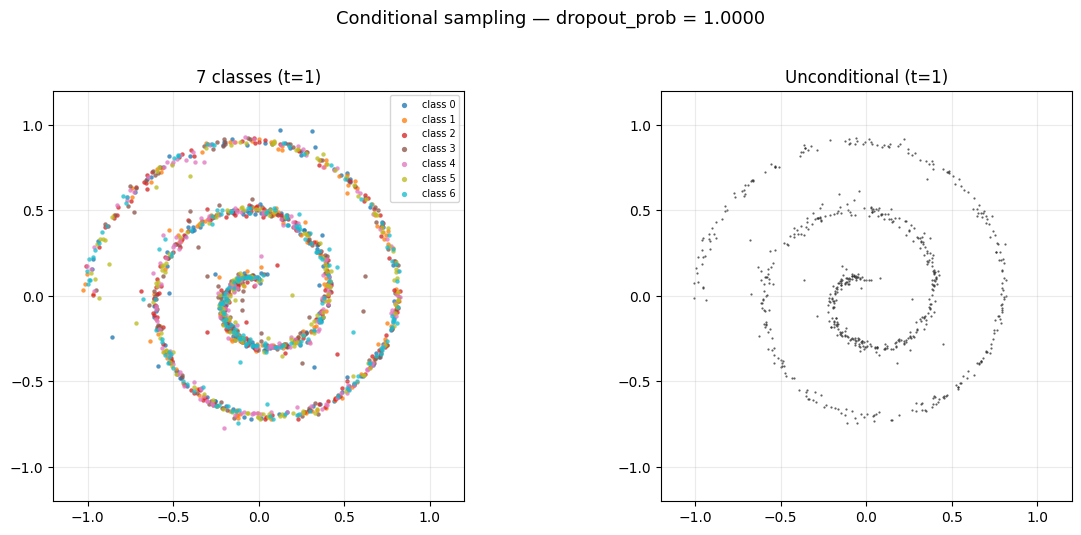

In [7]:
num_classes = SwissrollWithLabel.NUM_CLASSES
n_per_class = 200
n_uncond_pts = 600

try:
    cmap_cls = plt.colormaps["tab10"].resampled(num_classes)
except AttributeError:
    cmap_cls = plt.cm.get_cmap("tab10", num_classes)

for run_i, dp in enumerate(DROPOUTS):
    cond_model = trained_models[run_i]
    cond_model.eval()
    fig, (ax_cond, ax_unc) = plt.subplots(1, 2, figsize=(12.5, 5.2))

    for label in range(num_classes):
        x0 = sample_noise(n_per_class, device=device, seed=label)
        label_t = torch.full((n_per_class,), label, dtype=torch.long, device=device)
        traj = sample_trajectory(
            x0,
            lambda x, t, c=label_t: cond_model(x, t, c),
            n_steps=80,
        )
        x1 = traj["xs"][-1].cpu().numpy()
        col = cmap_cls(label / max(num_classes - 1, 1))
        ax_cond.scatter(
            x1[:, 0], x1[:, 1], s=10, alpha=0.78, color=col, label=f"class {label}", linewidths=0
        )
    ax_cond.set_aspect("equal")
    ax_cond.set_xlim(-1.2, 1.2)
    ax_cond.set_ylim(-1.2, 1.2)
    ax_cond.grid(True, alpha=0.25)
    ax_cond.set_title(f"7 classes (t=1)")
    ax_cond.legend(loc="best", fontsize=7, markerscale=1.2)

    label = num_classes
    x0 = sample_noise(n_uncond_pts, device=device, seed=label)
    label_t = torch.full((n_uncond_pts,), label, dtype=torch.long, device=device)
    traj = sample_trajectory(
        x0,
        lambda x, t, c=label_t: cond_model(x, t, c),
        n_steps=80,
    )
    x1u = traj["xs"][-1].cpu().numpy()
    ax_unc.scatter(x1u[:, 0], x1u[:, 1], marker=".", s=10, c="#2d2d2d", alpha=0.75, linewidths=0)
    ax_unc.set_aspect("equal")
    ax_unc.set_xlim(-1.2, 1.2)
    ax_unc.set_ylim(-1.2, 1.2)
    ax_unc.grid(True, alpha=0.25)
    ax_unc.set_title("Unconditional (t=1)")

    fig.suptitle(f"Conditional sampling — dropout_prob = {float(dp):.4f}", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
